## 1. Importing the necessary libraries
We first import the necessary dependencies for our analysis as well as our data for further processing.

The required libraries are:

In [1]:
import json
import nltk
import pandas as pd
import wordcloud as wc
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster import hierarchy as sch
from umap import UMAP
import datamapplot

from sklearn.feature_extraction.text import TfidfVectorizer
from util import model_topics

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gyevn\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
# Set this variable to true if only want to process information for the titles but not the astracts. Otherwise, both the title and the abstract will be processed.
use_title_only = False

# Set this variable to choose which conference proceedings to process. The options are 'aies', 'facct', and 'both'.
conference = 'both'

In [3]:
# Load both JSON files for the AIES and FAccT proceedings and extract either the title or the abstract and title from the file.
aies = json.load(open('data/AIES.json', "r", encoding="utf-8"))
facct = json.load(open('data/FACCT.json', "r", encoding="utf-8"))

data = aies + facct if conference == 'both' else aies if conference == 'aies' else facct
corpus = []
dates = []

for paper in data:
    date = int(paper['issued']['date-parts'][0][0])
    if use_title_only:
        corpus.append(paper['title'])
    elif not use_title_only and 'abstract' in paper:
        corpus.append(paper['title'])
        dates.append(date)
        corpus.append(paper['abstract'])
        dates.append(date)

## 2. Wordcloud plotting
We will now define a function that will help us plot the wordcloud for the given text data of each conference proceedings.

In [ ]:
# Plot wordclouds
stemmer = nltk.SnowballStemmer(language='english')
analyzer = TfidfVectorizer().build_analyzer()
def stemmed_words(doc):
    return (stemmer.stem(w.lower()) for w in analyzer(doc) if w not in nltk.corpus.stopwords.words("english"))
tfidf_vectorizer = TfidfVectorizer(analyzer=stemmed_words)
vecs = tfidf_vectorizer.fit_transform(corpus)
tfidf_scores = pd.DataFrame(vecs.todense().tolist(), columns=tfidf_vectorizer.get_feature_names_out()).T.sum(axis=1)

# Save scores to file
tfidf_scores.to_csv(f"output/tfidf_scores-{conference}.csv")

tfidf_scores.sort_values(ascending=False).head(10)

In [ ]:
wordcloud = wc.WordCloud(width=1000, height=1000, background_color="white", colormap="tab10", random_state=42).generate_from_frequencies(tfidf_scores)
plt.figure(figsize=(10, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.tight_layout()
plt.savefig(f"output/wordcloud-{conference}.pdf")
plt.show()

In [ ]:
# Plot the top 30 scores from both the AIES and FAccT proceedings on a bar plot.
n_scores = 20

aies_scores = pd.read_csv("output/tfidf_scores-aies.csv", index_col=0).reset_index().rename(columns={"index": "Word", "0": "Score"})
aies_scores["Conference"] = "AIES"
facct_scores = pd.read_csv("output/tfidf_scores-facct.csv", index_col=0).reset_index().rename(columns={"index": "Word", "0": "Score"})
facct_scores["Conference"] = "FAccT"
scores = pd.concat([aies_scores, facct_scores], axis=0).sort_values("Score", ascending=False)
plt.figure(figsize=(7, 3))
sns.barplot(data=scores.head(n_scores), x="Word", y="Score", hue="Conference", palette="tab10")
plt.ylim(10, scores["Score"].max())
plt.xlabel("Word")
plt.ylabel("TF-IDF Score")
plt.title(f"Top {n_scores} TF-IDF Scores")
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig(f"output/tfidf_scores_comparison.pdf")
plt.show()

## 3. Topic analysis with BERTopic
We will now perform topic analysis on the titles and abstracts of the papers using the BERTopic library.

In [4]:
topic_model, embeddings = model_topics(corpus, dates, min_cluster_size=10)

2024-04-29 15:59:22,023 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2024-04-29 15:59:35,111 - BERTopic - Dimensionality - Completed ✓
2024-04-29 15:59:35,114 - BERTopic - Cluster - Start clustering the reduced embeddings
2024-04-29 15:59:35,214 - BERTopic - Cluster - Completed ✓
2024-04-29 15:59:35,220 - BERTopic - Representation - Extracting topics from clusters using representation models.
2024-04-29 15:59:35,669 - BERTopic - Representation - Completed ✓
2024-04-29 15:59:35,923 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


In [ ]:
print(topic_model.get_document_info(corpus))
fig = topic_model.visualize_topics()
fig.write_html(f"output/topics-{conference}.html", include_mathjax = 'cdn')
fig.show()

In [12]:
linkage_function = lambda x: sch.linkage(x, 'single', optimal_ordering=True)
hierarchical_topics = topic_model.hierarchical_topics(corpus, linkage_function=linkage_function)
fig = topic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)
fig.show()

100%|██████████| 30/30 [00:00<00:00, 92.55it/s]


In [ ]:
fig = topic_model.visualize_heatmap()

AttributeError: 'Figure' object has no attribute 'save'

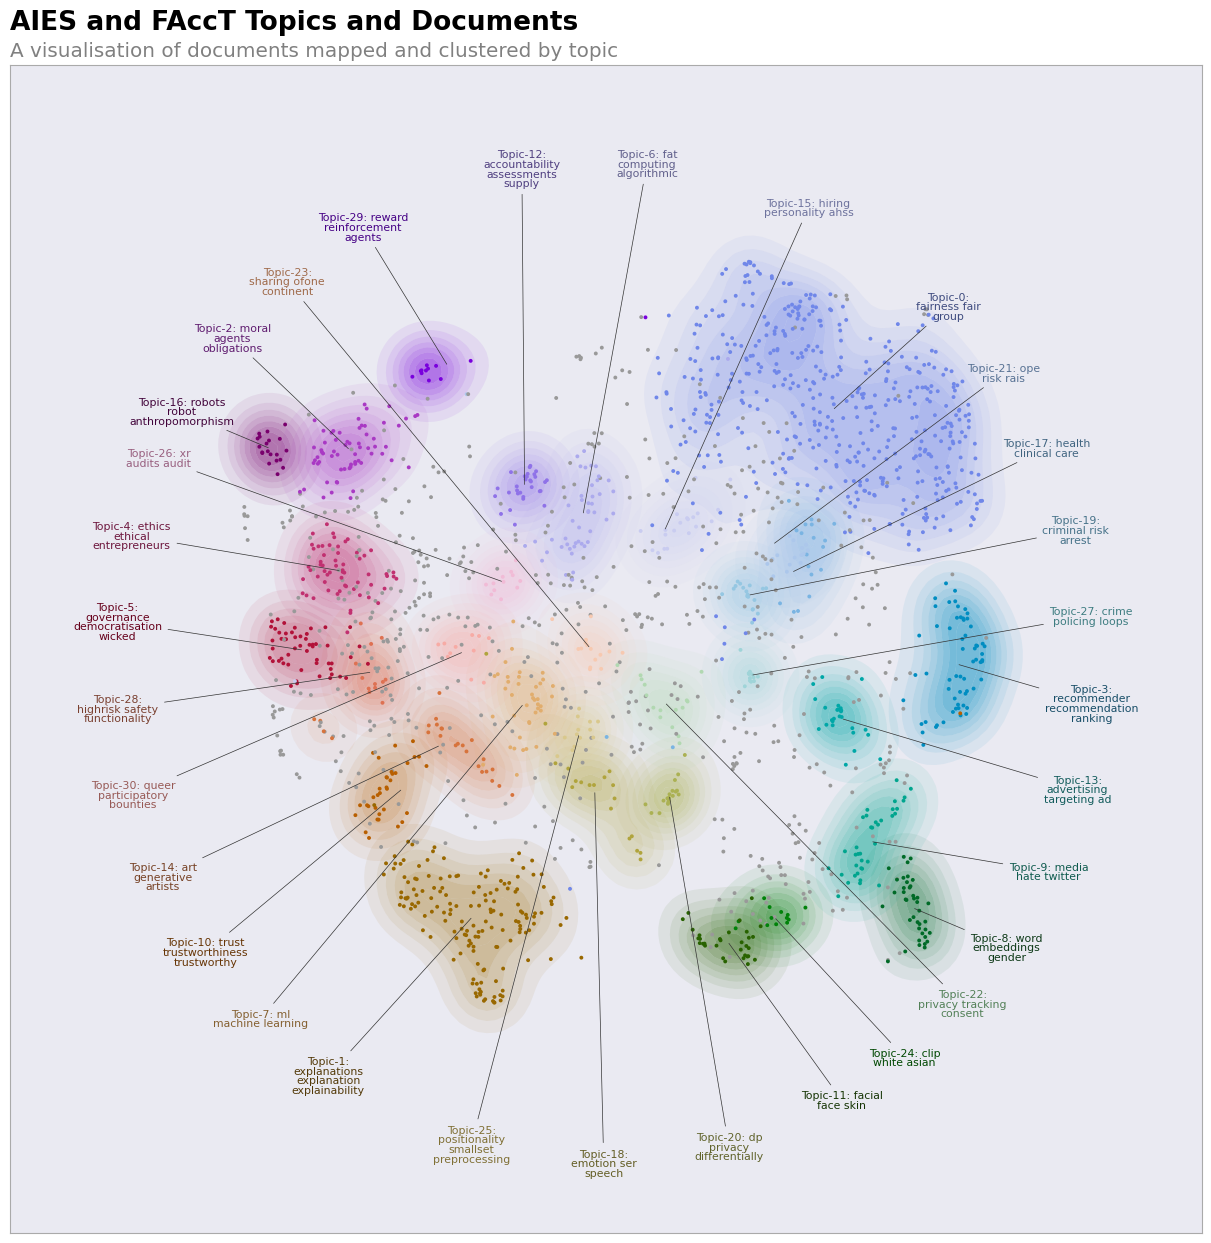

In [6]:
fig = topic_model.visualize_document_datamap(corpus, 
                                             title="AIES and FAccT Topics and Documents", 
                                             sub_title="A visualisation of documents mapped and clustered by topic", 
                                             embeddings=embeddings)
fig.savefig("output/datamap.pdf")
fig.show()

In [8]:
fig.savefig("output/datamap.pdf", bbox_inches='tight')

In [ ]:
# Run the visualization with the original embeddings
fig = topic_model.visualize_documents(corpus, embeddings=embeddings)
fig.show()

In [ ]:
reduced_embeddings = UMAP(n_neighbors=10, n_components=2, min_dist=0.0, metric='cosine').fit_transform(embeddings)
fig = topic_model.visualize_documents(corpus, reduced_embeddings=reduced_embeddings)
fig.show()

In [ ]:
fig = topic_model.visualize_barchart()
fig.show()

In [10]:
topics_over_time = topic_model.topics_over_time(corpus, dates)
fig = topic_model.visualize_topics_over_time(topics_over_time, topics=list(range(1, 11)))
fig.show()

6it [00:01,  3.13it/s]


In [ ]:
len(corpus), len(dates)